# 07 — Multi-Armed Bandits: Exploration vs Exploitation
**References:** Thompson (1933) · Lai & Robbins (1985) · Auer et al. (2002) · Russo et al. (2018)

## Narrative thread
```
Explore/exploit tradeoff -> Regret -> Epsilon-greedy -> UCB -> Thompson sampling -> Comparison
```

## The explore/exploit tradeoff

You have $K$ arms (variants). Pulling arm $k$ gives reward $r \sim P_k$ with mean $\mu_k$.
Goal: maximize **cumulative reward** over $T$ rounds.

**A/B test framing:** a fixed experiment assigns 50/50 traffic for $T$ observations. If arm 2 is better, you "waste" half the traffic on arm 1 during the experiment.

**Bandit framing:** adaptively allocate more traffic to better arms as you learn.

## Regret

The **expected regret** after $T$ rounds:
$$\mathcal{R}(T) = T \mu^* - \sum_{t=1}^T \mathbb{E}[r_t]$$

where $\mu^* = \max_k \mu_k$ is the optimal arm's mean.

**Lai-Robbins lower bound (1985):** for any consistent policy:
$$\liminf_{T\to\infty} \frac{\mathcal{R}(T)}{\ln T} \geq \sum_{k: \mu_k < \mu^*} \frac{\mu^* - \mu_k}{\text{KL}(P_k, P^*)}$$

No algorithm can grow regret slower than $O(\ln T)$.

## Algorithms

### Epsilon-greedy
With probability $\varepsilon$: explore (pull random arm).
With probability $1-\varepsilon$: exploit (pull best arm so far).

Simple but never focuses — keeps wasting $\varepsilon$ fraction on random arms even when optimal arm is known.

### UCB1 — Upper Confidence Bound (Auer et al., 2002)

$$\text{arm}_t = \arg\max_k \left[ \hat{\mu}_k + \sqrt{\frac{2 \ln t}{n_k}} \right]$$

"Optimism in the face of uncertainty" — inflate uncertain estimates.
Achieves $O(\ln T)$ regret, matching the Lai-Robbins lower bound up to constants.

### Thompson Sampling (Thompson, 1933)

Bayesian. Maintain posterior $P(\mu_k | \text{data})$ for each arm.
Each round: sample $\tilde{\mu}_k \sim P(\mu_k | \text{data})$, then pull $\arg\max_k \tilde{\mu}_k$.

For Bernoulli rewards: use Beta-Binomial conjugate.
- Prior: $\theta_k \sim \text{Beta}(1, 1)$
- Update: after $s$ successes, $f$ failures: $\theta_k \sim \text{Beta}(1+s, 1+f)$
- Sample and pull the max.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import product

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

Arms: ['A', 'B', 'C', 'D']  true CTR: [0.1  0.15 0.25 0.18]  best arm: C (mu*=0.25)


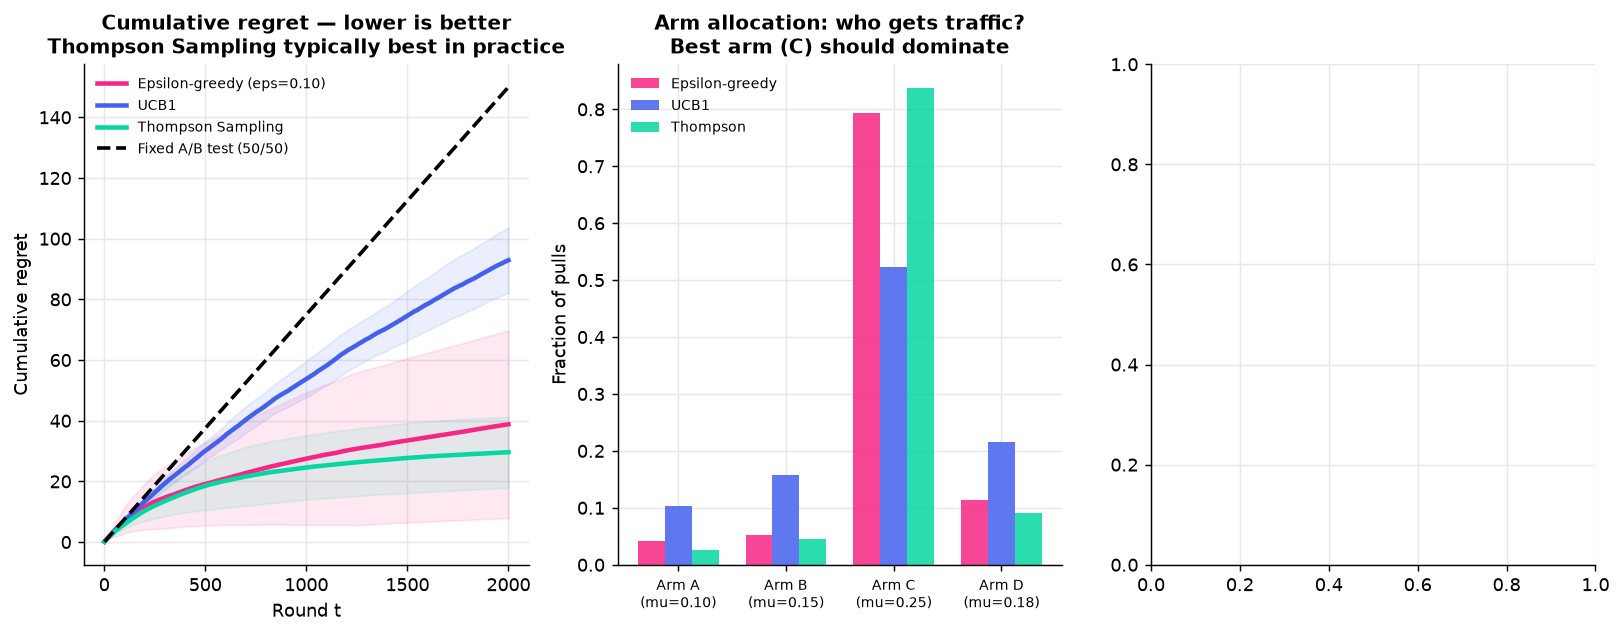

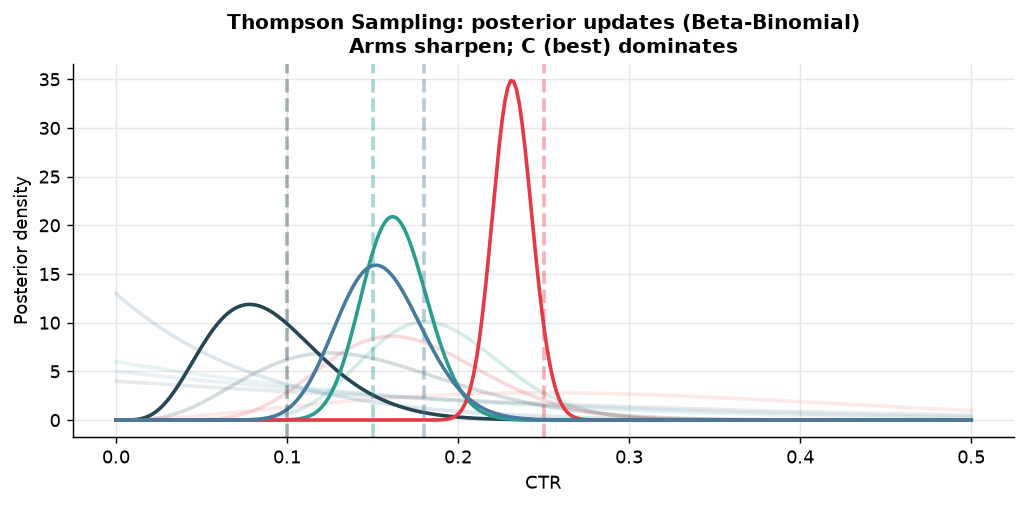

<Figure size 832x624 with 0 Axes>

In [2]:
# ── Multi-Armed Bandit: 4 arms (e.g. 4 button colors) ────────────────────
np.random.seed(42)

K = 4; T = 2000
true_mu = np.array([0.10, 0.15, 0.25, 0.18])   # true CTR for each arm
best_arm = np.argmax(true_mu)
print(f'Arms: {["A","B","C","D"]}  true CTR: {true_mu}  best arm: {["A","B","C","D"][best_arm]} (mu*={true_mu[best_arm]})')

def pull(arm):
    return np.random.binomial(1, true_mu[arm])

# ── Epsilon-greedy ────────────────────────────────────────────────────────
def epsilon_greedy(eps=0.10):
    counts = np.zeros(K); rewards_sum = np.zeros(K); regret = []
    cum_regret = 0
    for t in range(1, T+1):
        if np.random.random() < eps or counts.min() == 0:
            arm = np.random.randint(K)
        else:
            arm = np.argmax(rewards_sum / np.maximum(counts, 1))
        r = pull(arm)
        counts[arm] += 1; rewards_sum[arm] += r
        cum_regret += true_mu[best_arm] - true_mu[arm]
        regret.append(cum_regret)
    return np.array(regret), counts

# ── UCB1 ──────────────────────────────────────────────────────────────────
def ucb1():
    counts = np.zeros(K); rewards_sum = np.zeros(K); regret = []
    cum_regret = 0
    for t in range(1, T+1):
        if counts.min() == 0:
            arm = np.argmin(counts)
        else:
            ucb = rewards_sum/counts + np.sqrt(2*np.log(t)/counts)
            arm = np.argmax(ucb)
        r = pull(arm)
        counts[arm] += 1; rewards_sum[arm] += r
        cum_regret += true_mu[best_arm] - true_mu[arm]
        regret.append(cum_regret)
    return np.array(regret), counts

# ── Thompson Sampling ─────────────────────────────────────────────────────
def thompson_sampling():
    alpha_ts = np.ones(K); beta_ts = np.ones(K)  # Beta(1,1) prior
    regret = []; counts = np.zeros(K)
    cum_regret = 0
    for t in range(T):
        samples = np.random.beta(alpha_ts, beta_ts)
        arm = np.argmax(samples)
        r = pull(arm)
        alpha_ts[arm] += r; beta_ts[arm] += 1 - r
        counts[arm] += 1
        cum_regret += true_mu[best_arm] - true_mu[arm]
        regret.append(cum_regret)
    return np.array(regret), counts

# Run each algorithm B times for smooth curves
B_runs = 50
reg_eg = np.zeros((B_runs, T)); reg_ucb = np.zeros((B_runs, T)); reg_ts = np.zeros((B_runs, T))
cts_eg = np.zeros((B_runs, K)); cts_ucb = np.zeros((B_runs, K)); cts_ts = np.zeros((B_runs, K))
for b in range(B_runs):
    np.random.seed(b)
    reg_eg[b], cts_eg[b] = epsilon_greedy(eps=0.10)
    reg_ucb[b], cts_ucb[b] = ucb1()
    reg_ts[b], cts_ts[b] = thompson_sampling()

# A/B test baseline: always 50/50 between arm 0 and best arm
reg_ab = np.cumsum(np.full(T, true_mu[best_arm] - np.mean(true_mu[[0, best_arm]])))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cumulative regret
ax = axes[0]
t_range = np.arange(1, T+1)
for reg, name, color in [(reg_eg, 'Epsilon-greedy (eps=0.10)', '#f72585'),
                           (reg_ucb, 'UCB1', '#4361ee'),
                           (reg_ts, 'Thompson Sampling', '#06d6a0')]:
    ax.plot(t_range, reg.mean(axis=0), color=color, lw=2.5, label=name)
    ax.fill_between(t_range, reg.mean(axis=0)-reg.std(axis=0),
                     reg.mean(axis=0)+reg.std(axis=0), color=color, alpha=0.1)
ax.plot(t_range, reg_ab, 'k--', lw=2, label='Fixed A/B test (50/50)')
ax.set_xlabel('Round t'); ax.set_ylabel('Cumulative regret')
ax.set_title('Cumulative regret — lower is better\nThompson Sampling typically best in practice')
ax.legend(fontsize=8)

# Arm allocation (fraction of pulls per arm)
ax2 = axes[1]
arm_labels = [f'Arm {["A","B","C","D"][i]}\n(mu={true_mu[i]:.2f})' for i in range(K)]
x_pos = np.arange(K)
w = 0.25
for i, (cts, name, color) in enumerate([(cts_eg, 'Epsilon-greedy', '#f72585'),
                                          (cts_ucb, 'UCB1', '#4361ee'),
                                          (cts_ts, 'Thompson', '#06d6a0')]):
    fracs = cts.mean(axis=0) / T
    ax2.bar(x_pos + (i-1)*w, fracs, w, color=color, alpha=0.85, label=name)
ax2.set_xticks(x_pos); ax2.set_xticklabels(arm_labels, fontsize=8)
ax2.set_ylabel('Fraction of pulls')
ax2.set_title('Arm allocation: who gets traffic?\nBest arm (C) should dominate')
ax2.legend(fontsize=8)

# Thompson posterior evolution
alpha_plot = np.ones(K); beta_plot = np.ones(K)
fig_posterior, ax_p = plt.subplots(1, 1, figsize=(8, 4))
theta = np.linspace(0, 0.5, 300)
checkpoints = [20, 200, 2000]
colors_check = ['#e9c46a', '#f4a261', '#e76f51']
colors_arms = ['#264653','#2a9d8f','#e63946','#457b9d']
for t_check, c_check in zip(checkpoints, colors_check):
    np.random.seed(42)
    a_t = np.ones(K); b_t = np.ones(K)
    for _ in range(t_check):
        s = np.random.beta(a_t, b_t); arm = np.argmax(s); r = pull(arm)
        a_t[arm] += r; b_t[arm] += 1 - r
    for k in range(K):
        pdf = stats.beta(a_t[k], b_t[k]).pdf(theta)
        ax_p.plot(theta, pdf, color=colors_arms[k], alpha=float(t_check)/2000*0.9+0.1,
                  lw=2, label=f'Arm {["A","B","C","D"][k]} t={t_check}')
for k in range(K):
    ax_p.axvline(true_mu[k], color=colors_arms[k], lw=2, linestyle='--', alpha=0.4)
ax_p.set_xlabel('CTR'); ax_p.set_ylabel('Posterior density')
ax_p.set_title('Thompson Sampling: posterior updates (Beta-Binomial)\nArms sharpen; C (best) dominates')
plt.tight_layout()
plt.show()
axes[2].axis('off')
plt.tight_layout()
plt.show()